# Company Deep Dive

An interactive research notebook for investigating a single Swiss company.
Walk through the full profile, board members, corporate changes,
risk assessment, and network graph — all from the VynCo API.

```bash
pip install vynco matplotlib seaborn networkx
```

In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import vynco

sns.set_theme(style="whitegrid", font_scale=1.1)
ACCENT = "#2e86ab"
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

client = vynco.Client()

# --- Find the target company by search (UBS has rich data) ---
search = client.companies.list(query="UBS", page_size=1)
TARGET_UID = search.data.items[0].uid
print(f"Target: {search.data.items[0].name} ({TARGET_UID})")

Target: UBS SA (CHE-101.329.561)


## 1. Company Profile Card

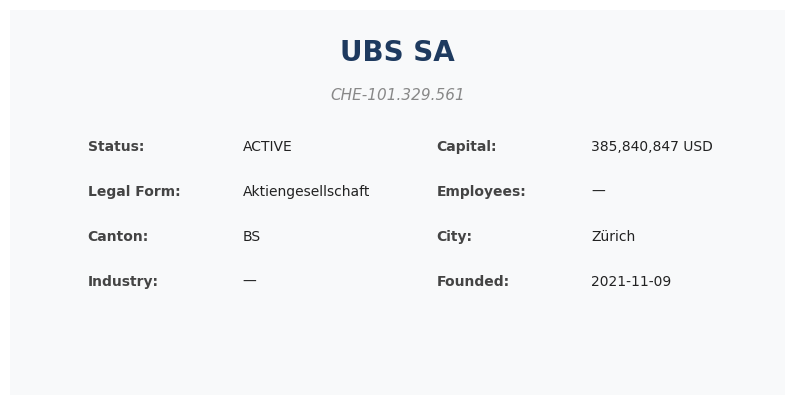

In [2]:
company = client.companies.get(TARGET_UID).data

# Build a styled profile card
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis("off")

# Background
rect = mpatches.FancyBboxPatch((0.2, 0.2), 9.6, 5.6, boxstyle="round,pad=0.3",
                                facecolor="#f8f9fa", edgecolor="#1e3a5f", linewidth=2)
ax.add_patch(rect)

# Company name
ax.text(5, 5.2, company.name, fontsize=20, fontweight="bold", ha="center",
        color="#1e3a5f")
ax.text(5, 4.6, company.uid, fontsize=11, ha="center", color="#888", style="italic")

# Details in two columns
left = [
    ("Status", company.status),
    ("Legal Form", company.legal_form),
    ("Canton", company.canton),
    ("Industry", company.industry),
]
right = [
    ("Capital", f"{company.share_capital:,.0f} {company.currency}" if company.share_capital else "\u2014"),
    ("Employees", str(company.employee_count or "\u2014")),
    ("City", company.address_city or "\u2014"),
    ("Founded", company.founding_date or "\u2014"),
]

for i, (label, value) in enumerate(left):
    y = 3.8 - i * 0.7
    ax.text(1.0, y, f"{label}:", fontsize=10, fontweight="bold", color="#444")
    ax.text(3.0, y, str(value or "\u2014"), fontsize=10, color="#222")

for i, (label, value) in enumerate(right):
    y = 3.8 - i * 0.7
    ax.text(5.5, y, f"{label}:", fontsize=10, fontweight="bold", color="#444")
    ax.text(7.5, y, str(value), fontsize=10, color="#222")

plt.savefig(f"{FIG_DIR}/company_profile_card.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

## 2. Board of Directors

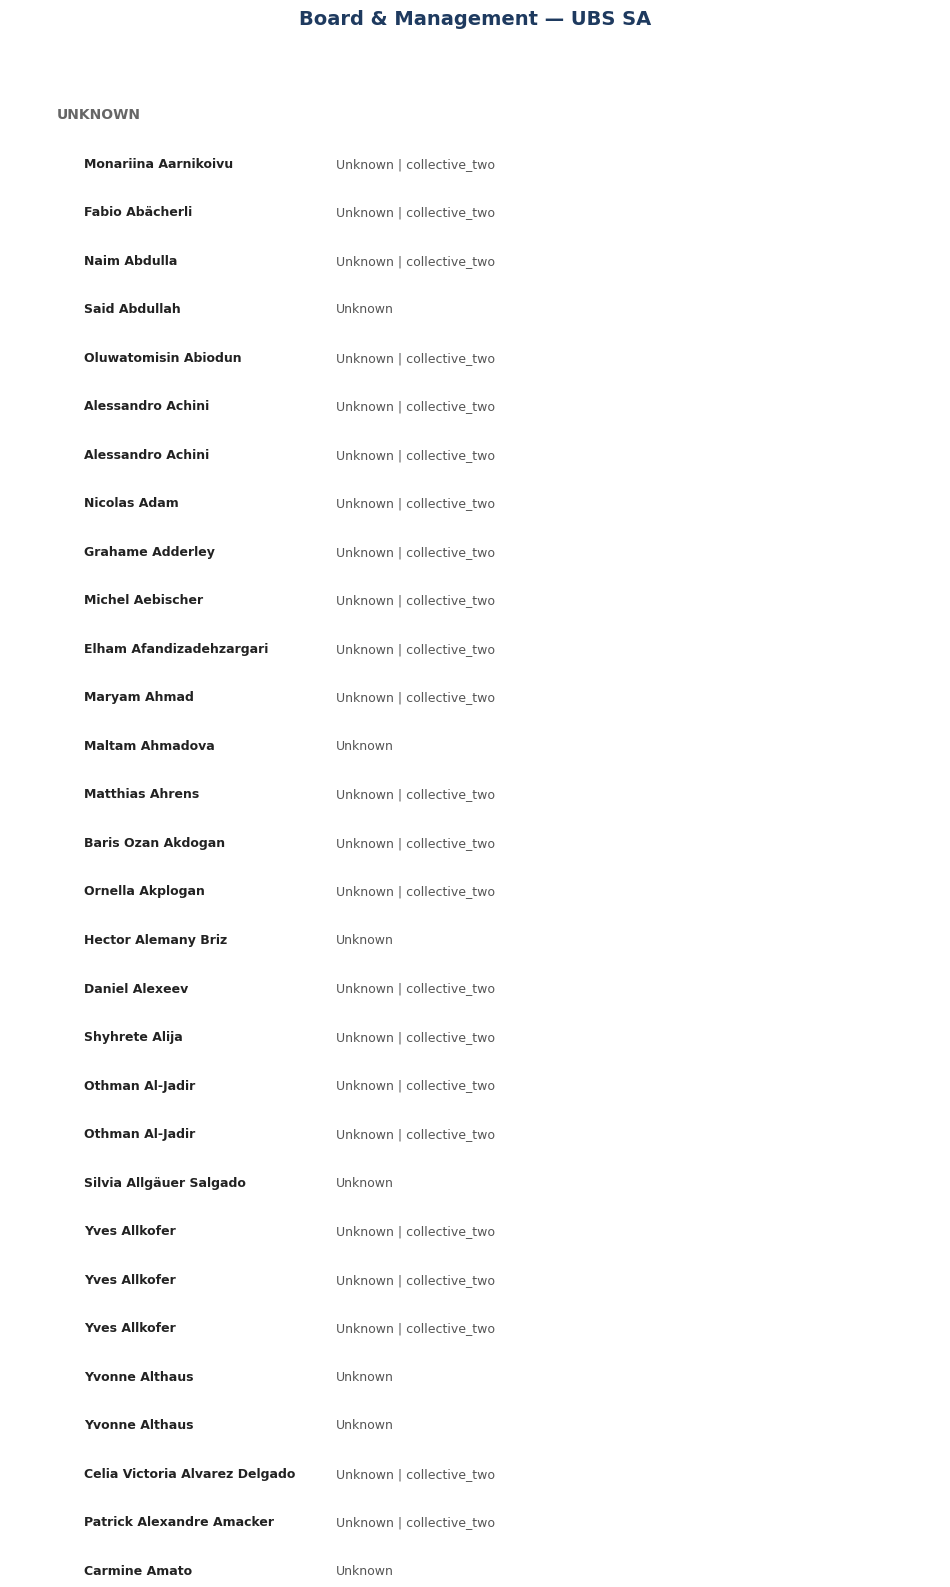

Showing 30 of 1100 persons in 1 categories


In [3]:
members = client.persons.board_members(TARGET_UID).data

# Group by role category — limit to first 30 for readability
categories: dict[str, list] = {}
for m in members[:30]:
    categories.setdefault(m.role_category, []).append(m)

display_count = sum(len(v) for v in categories.values())
fig, ax = plt.subplots(figsize=(12, max(4, display_count * 0.4 + 2)))
ax.axis("off")

cat_colors = {"board": "#1e3a5f", "management": "#2e86ab", "auditor": "#a23b72",
              "signatory": "#f18f01"}
y = 1.0
row_height = 0.045

ax.text(0.5, y + 0.02, f"Board & Management — {company.name}",
        fontsize=14, fontweight="bold", ha="center", transform=ax.transAxes, color="#1e3a5f")

for cat, cat_members in categories.items():
    y -= row_height * 1.5
    color = cat_colors.get(cat, "#666")
    ax.text(0.05, y, cat.upper(), fontsize=10, fontweight="bold",
            transform=ax.transAxes, color=color)
    for m in cat_members:
        y -= row_height
        name = f"{m.first_name} {m.last_name}"
        detail = f"{m.role}"
        if m.signing_authority:
            detail += f" | {m.signing_authority}"
        if m.since:
            detail += f" | since {m.since}"
        ax.text(0.08, y, name, fontsize=9, fontweight="bold",
                transform=ax.transAxes, color="#222")
        ax.text(0.35, y, detail, fontsize=9,
                transform=ax.transAxes, color="#555")

plt.savefig(f"{FIG_DIR}/board_members.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Showing {display_count} of {len(members)} persons in {len(categories)} categories")

## 3. Risk Score Breakdown

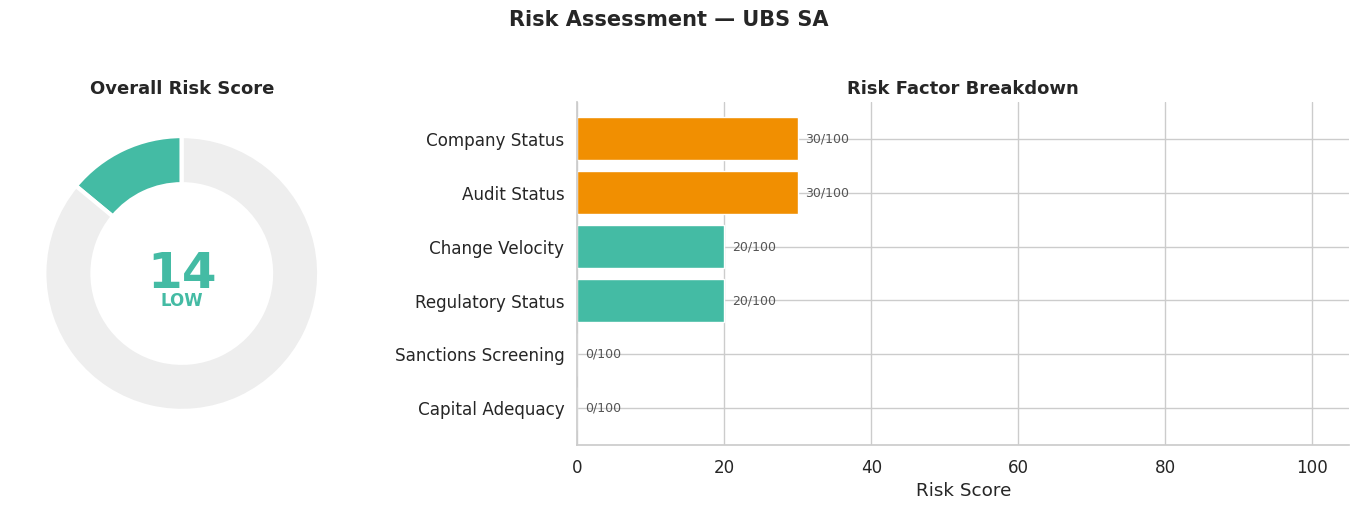

  Company Status             30/100  Status: ACTIVE
  Audit Status               30/100  Auditor category: Unknown
  Change Velocity            20/100  4 events in last 180 days
  Regulatory Status          20/100  Not FINMA regulated
  Sanctions Screening         0/100  No sanctions matches found
  Capital Adequacy            0/100  Share capital: CHF 385840847


In [4]:
risk = client.ai.risk_score(uid=TARGET_UID).data

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 2]})

# Gauge-style overall score
ax = axes[0]
score = risk.overall_score
level_colors = {"low": "#44bba4", "medium": "#f18f01", "high": "#e94f37", "critical": "#c73e1d"}
color = level_colors.get(risk.risk_level, "#999")

ax.pie([score, 100 - score], colors=[color, "#eee"], startangle=90,
       wedgeprops={"width": 0.35, "edgecolor": "white", "linewidth": 3})
ax.text(0, 0, f"{score}", fontsize=36, fontweight="bold", ha="center", va="center",
        color=color)
ax.text(0, -0.2, risk.risk_level.upper(), fontsize=12, ha="center", va="center",
        color=color, fontweight="bold")
ax.set_title("Overall Risk Score", fontsize=13, fontweight="bold")

# Factor breakdown
ax2 = axes[1]
factors = sorted(risk.breakdown, key=lambda f: f.score, reverse=True)
f_names = [f.factor for f in factors]
f_scores = [f.score for f in factors]
f_colors = ["#44bba4" if s < 30 else "#f18f01" if s < 60 else "#e94f37" for s in f_scores]

bars = ax2.barh(f_names[::-1], f_scores[::-1], color=f_colors[::-1],
                edgecolor="white", linewidth=1)
for bar, score_val in zip(bars, f_scores[::-1]):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
             f"{score_val}/100", va="center", fontsize=9, color="#555")

ax2.set_xlim(0, 105)
ax2.set_xlabel("Risk Score")
ax2.set_title("Risk Factor Breakdown", fontsize=13, fontweight="bold")
ax2.spines[["top", "right"]].set_visible(False)

plt.suptitle(f"Risk Assessment — {risk.company_name}",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/risk_score.png", dpi=150, bbox_inches="tight")
plt.show()

# Print factor descriptions
for f in factors:
    print(f"  {f.factor:<25} {f.score:>3}/100  {f.description}")

## 4. Corporate Network Graph

Visualize the corporate network: companies as blue nodes, persons
as orange nodes, with edges showing their relationships.

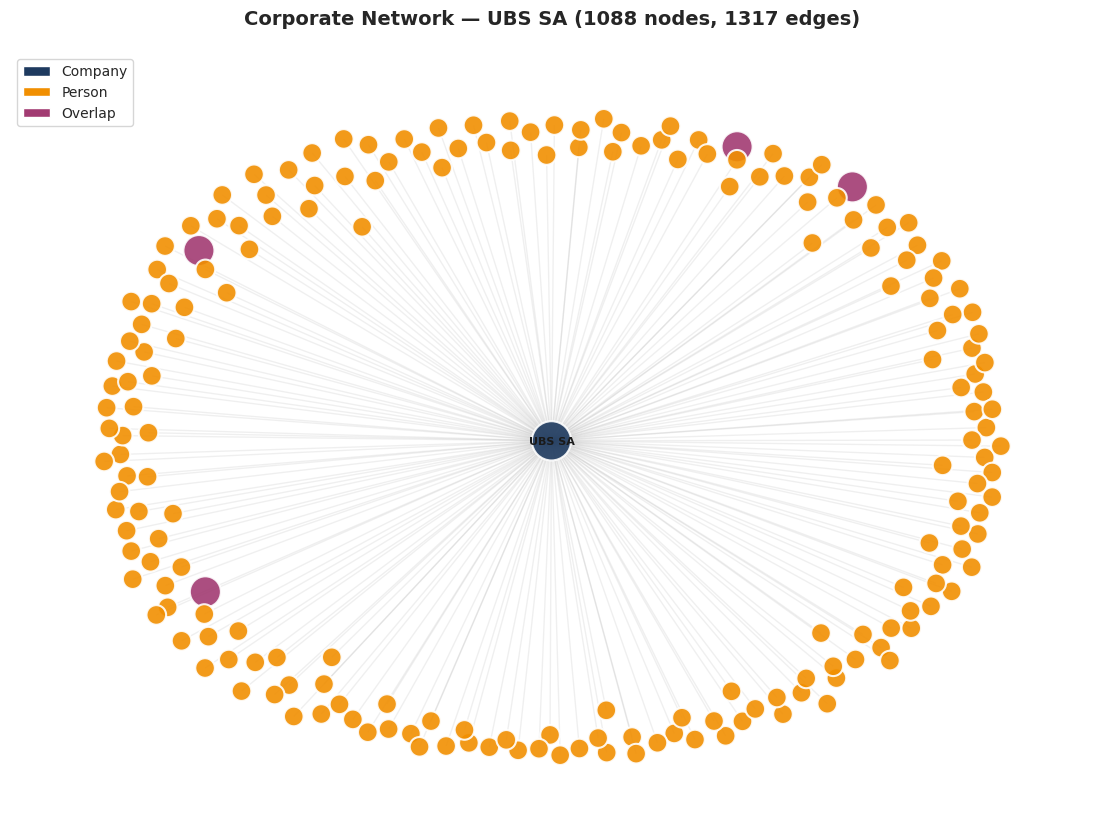

Full graph: 1088 nodes, 1317 edges (showing 200 nodes)


In [5]:
graph = client.graph.get(TARGET_UID).data

G = nx.Graph()
for node in graph.nodes:
    G.add_node(node.id, name=node.name, node_type=node.node_type)
for link in graph.links:
    G.add_edge(link.source, link.target, link_type=link.link_type, label=link.label)

# Limit to 200 nodes for a readable visualization
if len(G.nodes) > 200:
    # Keep the root node and a random sample of connected nodes
    import random
    random.seed(42)
    root_nodes = [n for n in G.nodes if G.nodes[n].get("node_type") in ("root", "company")]
    other_nodes = [n for n in G.nodes if n not in root_nodes]
    keep = root_nodes + random.sample(other_nodes, min(200 - len(root_nodes), len(other_nodes)))
    G = G.subgraph(keep).copy()

# Color and size by type
node_colors = []
node_sizes = []
for n in G.nodes:
    ntype = G.nodes[n].get("node_type", "")
    if ntype in ("company", "root"):
        node_colors.append("#1e3a5f")
        node_sizes.append(800)
    elif ntype == "overlap":
        node_colors.append("#a23b72")
        node_sizes.append(500)
    else:
        node_colors.append("#f18f01")
        node_sizes.append(200)

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G, k=2.5, iterations=50, seed=42)

nx.draw_networkx_edges(G, pos, alpha=0.15, edge_color="#999", ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes,
                       alpha=0.9, edgecolors="white", linewidths=1.5, ax=ax)

# Label only root/company nodes to keep it readable
company_labels = {n: G.nodes[n]["name"][:25] for n in G.nodes
                  if G.nodes[n].get("node_type") in ("company", "root")}
nx.draw_networkx_labels(G, pos, company_labels, font_size=8, font_weight="bold", ax=ax)

# Legend
legend_elements = [
    mpatches.Patch(facecolor="#1e3a5f", edgecolor="white", label="Company"),
    mpatches.Patch(facecolor="#f18f01", edgecolor="white", label="Person"),
    mpatches.Patch(facecolor="#a23b72", edgecolor="white", label="Overlap"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=10)
ax.set_title(f"Corporate Network — {company.name} ({len(graph.nodes)} nodes, {len(graph.links)} edges)",
             fontsize=14, fontweight="bold", pad=20)
ax.axis("off")

plt.savefig(f"{FIG_DIR}/corporate_network.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()
print(f"Full graph: {len(graph.nodes)} nodes, {len(graph.links)} edges (showing {len(G.nodes)} nodes)")

## 5. Company Comparison

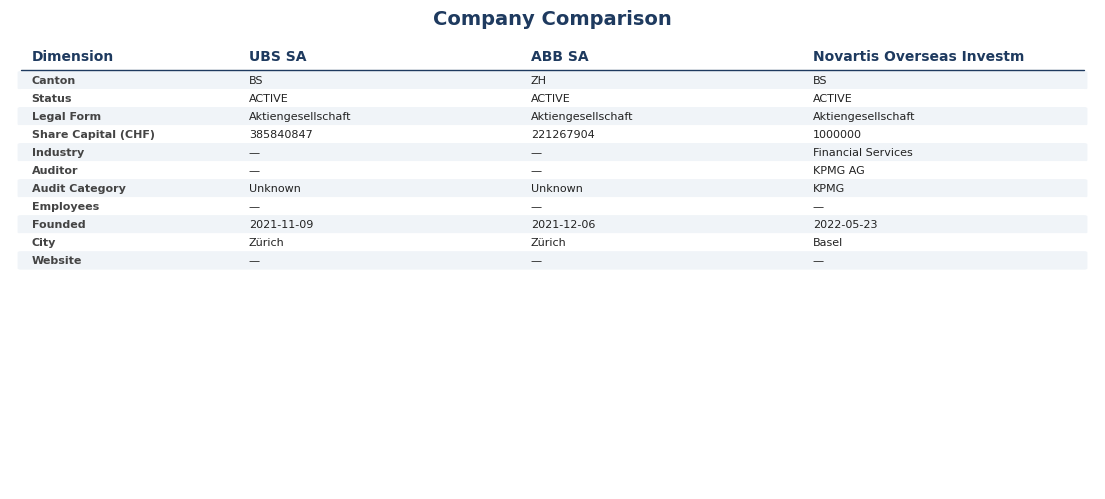

In [6]:
# Find UIDs dynamically
compare_uids = [TARGET_UID]
for q in ["ABB", "Novartis"]:
    r = client.companies.list(query=q, page_size=1)
    if r.data.items:
        compare_uids.append(r.data.items[0].uid)

compare = client.companies.compare(compare_uids).data

# Build comparison table as a figure
fig, ax = plt.subplots(figsize=(14, max(3, len(compare.dimensions) * 0.35 + 2)))
ax.axis("off")

# Column positions (adjust based on number of companies)
col_x = [0.02] + [0.22 + i * 0.26 for i in range(len(compare.names))]

# Header
header_y = 0.95
ax.text(col_x[0], header_y, "Dimension", fontsize=10, fontweight="bold",
        transform=ax.transAxes, color="#1e3a5f")
for j, name in enumerate(compare.names):
    ax.text(col_x[j + 1], header_y, name[:25], fontsize=10, fontweight="bold",
            transform=ax.transAxes, color="#1e3a5f")

# Separator line (using plot instead of axhline to allow transform)
ax.plot([0.01, 0.99], [header_y - 0.02, header_y - 0.02],
        color="#1e3a5f", linewidth=1, transform=ax.transAxes, clip_on=False)

# Data rows
row_h = 0.04
for i, dim in enumerate(compare.dimensions):
    y = header_y - 0.05 - i * row_h
    bg_color = "#f0f4f8" if i % 2 == 0 else "white"
    rect = mpatches.FancyBboxPatch((0.01, y - 0.01), 0.98, row_h - 0.005,
                                    boxstyle="round,pad=0.003",
                                    facecolor=bg_color, edgecolor="none",
                                    transform=ax.transAxes)
    ax.add_patch(rect)
    ax.text(col_x[0], y, dim.label, fontsize=8, fontweight="bold",
            transform=ax.transAxes, color="#444")
    for j, val in enumerate(dim.values):
        display = str(val)[:30] if val is not None else "\u2014"
        ax.text(col_x[j + 1], y, display, fontsize=8,
                transform=ax.transAxes, color="#222")

ax.set_title("Company Comparison", fontsize=14, fontweight="bold", color="#1e3a5f", pad=10)
plt.savefig(f"{FIG_DIR}/company_comparison.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

## 6. Nearby Companies (Geographic)

Find companies near a geographic location and plot them on a scatter map.

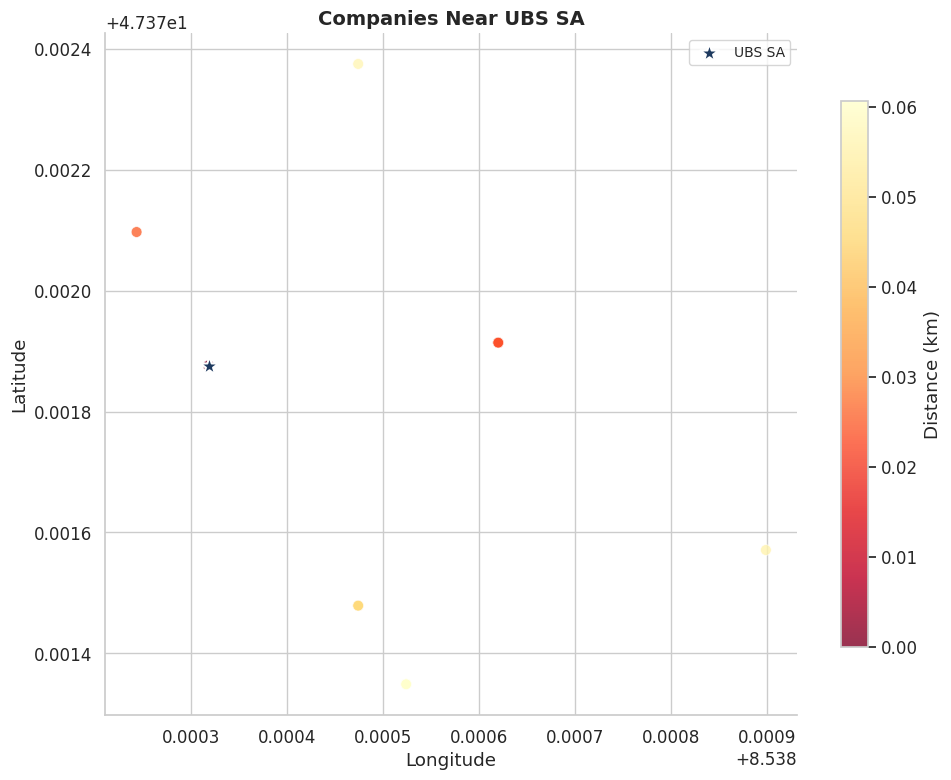

Found 50 companies within 5 km


In [7]:
# Use the target company's coordinates as center
lat = company.latitude or 47.45
lng = company.longitude or 8.55
nearby = client.companies.nearby(lat=lat, lng=lng, radius_km=5.0, limit=50).data

fig, ax = plt.subplots(figsize=(10, 8))

lats = [c.latitude for c in nearby]
lngs = [c.longitude for c in nearby]
dists = [c.distance for c in nearby]

scatter = ax.scatter(lngs, lats, c=dists, cmap="YlOrRd_r", s=60, alpha=0.8,
                     edgecolors="white", linewidths=0.5)
ax.scatter([lng], [lat], c="#1e3a5f", s=200, marker="*", zorder=10,
           edgecolors="white", linewidths=1.5, label=company.name)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
cbar.set_label("Distance (km)")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Companies Near {company.name}", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/nearby_companies.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Found {len(nearby)} companies within 5 km")